# DO Emulation & Calibration — Scaled Parameter Space

Calibration pipeline for CLIMBER-X DO variability using GP emulation and MCMC.

- **Inputs** scaled to **[0, 1]** using fixed *prior bounds* (`BoundsScaler`).
- **Outputs** standardised to **N(0, 1)** with a `StandardScaler`.
- **MCMC** samples directly in **[0, 1]^6**; prior is a multivariate KDE on the
  emulator training set (DO runs with `n_do_events ≥ N_DO_THRESHOLD`).
- Active dataset and all detection / threshold settings are controlled by the
  single `ACTIVE_DATASET` key in the configuration cell below.

## 1. Configuration

In [1]:
# ── Dataset configuration ─────────────────────────────────────────────────────
PPE_CONFIGS = {
    'data': {
        'data_dir':          'data',
        'run_length':        75000,
        'spinup_fraction':   0.02,
        'do_crossing_value': 5.0,
        'detection_mode':    'peak_walkback',
        'do_peak_threshold': 14.0,
        'prior_bounds': {
            'diff_dia_min':  (7.5e-6,   1.25e-5),
            'drag_topo_fac': (2.25,     3.75),
            'slope_max':     (7.5e-4,   1.25e-3),
            'diff_iso':      (1125,     1875),
            'diff_gm':       (1125,     1875),
            'diff_dia_max':  (1.125e-4, 1.875e-4),
        },
    },
    'data2': {
        'data_dir':          'data2',
        'run_length':        10000,
        'spinup_fraction':   0.1,
        'do_crossing_value': 3.6,
        'detection_mode':    'peak_walkback',
        'do_peak_threshold': 14.0,
        'prior_bounds': {
            'diff_dia_min':  (0.5e-5,  2.0e-5),
            'drag_topo_fac': (2.5,     3.5),
            'slope_max':     (0.5e-3,  2.0e-3),
            'diff_iso':      (500,     2000),
            'diff_gm':       (500,     2000),
            'diff_dia_max':  (1.0e-4,  2.0e-4),
        },
    },
    'do_region_75ky': {
        'data_dir':          'ppe_do_region_from_even_wider_500_75ky',
        'run_length':        75000,
        'spinup_fraction':   0.02,
        'do_crossing_value': 5.0,
        'detection_mode':    'peak_walkback',
        'do_peak_threshold': 14.0,
        'n_do_threshold':    5,
        'false_do_run_ids':  [26, 27, 31, 57, 80, 95, 126, 135, 139, 178, 195],
        'exclude_run_ids':   [],
        'prior_bounds': {
            'diff_dia_min':  (5e-7,   2.5e-5),
            'drag_topo_fac': (1.5,    5.5),
            'slope_max':     (1e-4,   4e-3),
            'diff_iso':      (100,    3000),
            'diff_gm':       (100,    3000),
            'diff_dia_max':  (5e-6,   4e-4),
        },
    },
    'do_region_wide_300_75ky': {
        'data_dir':          'ppe_do_region_wide_300_75ky',
        'run_length':        75000,
        'spinup_fraction':   0.02,
        'do_crossing_value': 5.0,
        'detection_mode':    'peak_walkback',
        'do_peak_threshold': 14.0,
        'pre_smooth_win':    0,
        'n_do_threshold':    5,
        'false_do_run_ids':  [],   # populate after inspecting plots
        'exclude_run_ids':   [],   # populate after inspecting plots
        # Bounds = range of ppe_wide_500_10ky (GPC training box used to sample this PPE)
        'prior_bounds': {
            'diff_dia_min':  (3.5e-6,  2.15e-5),
            'drag_topo_fac': (2.4,     3.6),
            'slope_max':     (3.5e-4,  2.15e-3),
            'diff_iso':      (350,     2150),
            'diff_gm':       (350,     2150),
            'diff_dia_max':  (9e-5,    2.1e-4),
        },
    },
    'do_region_wide_200_75ky_pDO_0.87': {
        'data_dir':          'ppe_do_region_wide_200_75ky_pDO_0.87',
        'run_length':        75000,
        'spinup_fraction':   0.02,
        'do_crossing_value': 5.0,
        'detection_mode':    'peak_walkback',
        'do_peak_threshold': 14.0,
        'pre_smooth_win':    0,
        'n_do_threshold':    10,
        # False-DO: algorithm said DO but visual inspection disagrees
        'false_do_run_ids':  [51, 88],
        # Exclude entirely: transitional (116,147,166 flattened mid-run) or
        # uncharacteristic detection (8,128,149,162,164,182)
        'exclude_run_ids':   [8, 116, 128, 147, 149, 162, 164, 166, 182],
        # Same prior box as do_region_wide_300_75ky — both sampled from the
        # same wider GPC region, just with a higher P(DO) > 0.87 cut
        'prior_bounds': {
            'diff_dia_min':  (3.5e-6,  2.15e-5),
            'drag_topo_fac': (2.4,     3.6),
            'slope_max':     (3.5e-4,  2.15e-3),
            'diff_iso':      (350,     2150),
            'diff_gm':       (350,     2150),
            'diff_dia_max':  (9e-5,    2.1e-4),
        },
    },
    'do_region_wide_700_75ky_pDO_0.7': {
        'data_dir':          'ppe_do_region_wide_700_75ky_pDO_0.7',
        'run_length':        75000,
        'spinup_fraction':   0.02,
        'do_crossing_value': 5.0,
        'detection_mode':    'peak_walkback',
        'do_peak_threshold': 14.0,
        'pre_smooth_win':    0,
        'n_do_threshold':    10,
        'false_do_run_ids':  [151, 184, 280, 311, 593, 600, 681],   # populate after inspecting plots
        'exclude_run_ids':   [6, 7, 42, 65, 80, 92, 95, 103, 119, 122, 137, 146, 166, 187, 188, 190, 196, 206, 212, 213, 215, 216, 220, 251, 
                             258, 260, 264, 283, 285, 295, 314, 325, 327, 335, 339, 347, 359, 366, 584, 585, 586, 589, 616, 622, 634, 635, 644, 651, 655, 677, 694, 696, 699],   # populate after inspecting plots
        # Same prior box — sampled from the same wider GPC region
        'prior_bounds': {
            'diff_dia_min':  (3.5e-6,  2.15e-5),
            'drag_topo_fac': (2.4,     3.6),
            'slope_max':     (3.5e-4,  2.15e-3),
            'diff_iso':      (350,     2150),
            'diff_gm':       (350,     2150),
            'diff_dia_max':  (9e-5,    2.1e-4),
        },
    },
    'do_region_10ky': {
        'data_dir':          'ppe_do_region_300_10ky',
        'run_length':        10000,
        'spinup_fraction':   0.2,
        'do_crossing_value': 5.0,
        'detection_mode':    'peak_walkback',
        'do_peak_threshold': 14.0,
        'loess_span':        0.19,
        'do_min_spacing':    600,
        'pre_smooth_win':    0,
        'n_do_threshold':    3,
        'false_do_run_ids':  [],
        'exclude_run_ids':   [],
        # Bounds = range of ppe_wide_500_10ky (the PPE the GPC was trained on),
        # which is what the MH sampler was clipped to when generating this PPE.
        'prior_bounds': {
            'diff_dia_min':  (3.5e-6,  2.15e-5),
            'drag_topo_fac': (2.4,     3.6),
            'slope_max':     (3.5e-4,  2.15e-3),
            'diff_iso':      (350,     2150),
            'diff_gm':       (350,     2150),
            'diff_dia_max':  (9e-5,    2.1e-4),
        },
    },
}

# ── Active dataset(s) — single string or list of keys ─────────────────────────
ACTIVE_DATASET = 'do_region_wide_200_75ky_pDO_0.87'          # single dataset
#ACTIVE_DATASET = ['do_region_wide_700_75ky_pDO_0.7',
#                   'do_region_wide_200_75ky_pDO_0.87']        # combined#

# Normalise to list (single dataset path is identical to list of length 1)
active_datasets = [ACTIVE_DATASET] if isinstance(ACTIVE_DATASET, str) else list(ACTIVE_DATASET)

# Shared detection / MCMC settings taken from the first (or only) dataset.
# When combining PPEs they must share these settings.
cfg               = PPE_CONFIGS[active_datasets[0]]
spinup_fraction   = cfg['spinup_fraction']
do_crossing_value = cfg['do_crossing_value']
detection_mode    = cfg['detection_mode']
do_peak_threshold = cfg['do_peak_threshold']
prior_bounds      = cfg['prior_bounds']
param_names       = list(prior_bounds.keys())

loess_span     = cfg.get('loess_span',     0.02)
do_min_spacing = cfg.get('do_min_spacing', 600)
pre_smooth_win = cfg.get('pre_smooth_win', 0)
N_DO_THRESHOLD = cfg.get('n_do_threshold', 27)

DEFAULT_RUN_FILE = '../emulator/climberx_output/default_long_run/ocn_ts.nc'
N_PCA = 5

print(f'Active dataset(s): {active_datasets}')
print(f'Run length      : {cfg["run_length"]} yr')
print(f'Spinup          : {spinup_fraction*100:.0f}%')
print(f'loess_span      : {loess_span}  |  do_min_spacing: {do_min_spacing} yr')
print(f'n_DO threshold  : ≥ {N_DO_THRESHOLD}')
print(f'PCA components  : {N_PCA}')
for key in active_datasets:
    c = PPE_CONFIGS[key]
    print(f'  {key}:  false_DO={c.get("false_do_run_ids", [])}  '
          f'exclude={c.get("exclude_run_ids", [])}')

# Default CLIMBER-X parameter values (calibration target / reference)
PARAMS_DEFAULT = {
    'diff_dia_min':  1e-5,
    'drag_topo_fac': 3.0,
    'slope_max':     1e-3,
    'diff_iso':      1500.0,
    'diff_gm':       1500.0,
    'diff_dia_max':  1.5e-4,
}
import numpy as np
PARAMS_DEFAULT_ARR = np.array([PARAMS_DEFAULT[p] for p in param_names])

Active dataset(s): ['do_region_wide_200_75ky_pDO_0.87']
Run length      : 75000 yr
Spinup          : 2%
loess_span      : 0.02  |  do_min_spacing: 600 yr
n_DO threshold  : ≥ 10
PCA components  : 5
  do_region_wide_200_75ky_pDO_0.87:  false_DO=[51, 88]  exclude=[8, 116, 128, 147, 149, 162, 164, 166, 182]


## 2. Data Loading

In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import importlib

import summary_stats as _ss; importlib.reload(_ss)
from summary_stats import compute_summary_stats

import utils as _ut; importlib.reload(_ut)
from utils import (
    plot_amoc_analysis,
    plot_pca_variance, plot_pca_components,
    plot_pca_predictions, plot_stat_predictions,
    plot_pdf_comparison,
)

import gp_emulator as _gp; importlib.reload(_gp)
from gp_emulator import GPEmulatorPDF, crossvalidation, print_cv_summary

# ── Parameter table (one row per run slot, concatenated across all datasets) ──
params_list = []
for key in active_datasets:
    dir_i  = PPE_CONFIGS[key]['data_dir']
    info_i = pd.read_csv(f'{dir_i}/info.txt', delimiter=r'\s+')
    _ocn   = [c for c in info_i.columns
               if c.startswith('ocn.') and c != 'ocn.l_noise_fw']
    params_list.append(info_i[['runid'] + _ocn])

ocn_cols = [c for c in params_list[0].columns if c.startswith('ocn.')]
params   = pd.concat(params_list, ignore_index=True)

print(f'Parameter table : {params.shape[0]} runs × {len(ocn_cols)} parameters'
      + (f'  ({" + ".join(active_datasets)})' if len(active_datasets) > 1 else ''))

Parameter table : 200 runs × 6 parameters


In [3]:
# ── Build file list (one slot per run ID, concatenated across all datasets) ───
# dataset_offsets: key → index of first slot in model_files for that dataset.
# Used downstream to map per-dataset run IDs to global indices.
dataset_offsets = {}
model_files     = []

for key in active_datasets:
    cfg_i       = PPE_CONFIGS[key]
    dir_i       = cfg_i['data_dir']
    exclude_set = set(cfg_i.get('exclude_run_ids', []))

    run_ids_in_dir = sorted(
        int(d) for d in os.listdir(dir_i)
        if os.path.isdir(os.path.join(dir_i, d)) and d.isdigit()
    )
    max_run_id = max(run_ids_in_dir)
    dataset_offsets[key] = len(model_files)

    for run_id in range(1, max_run_id + 1):
        fp = f'{dir_i}/{run_id}/ocn_ts.nc'
        if run_id in exclude_set:
            model_files.append(None)
        elif os.path.exists(fp):
            model_files.append(fp)
        else:
            model_files.append(None)

    excl = sorted(cfg_i.get('exclude_run_ids', []))
    print(f'{key}: {len(run_ids_in_dir)} runs, global offset={dataset_offsets[key]}'
          + (f', excluded={excl}' if excl else ''))

print(f'\nTotal slots: {len(model_files)}')

do_region_wide_200_75ky_pDO_0.87: 200 runs, global offset=0, excluded=[8, 116, 128, 147, 149, 162, 164, 166, 182]

Total slots: 200


## 3. Summary Statistics & PCA

In [4]:
from tqdm.notebook import tqdm
from sklearn.decomposition import PCA

expected_length = cfg['run_length']

# ── Pass 1: collect global AMOC range ────────────────────────────────────────
all_amoc_concat = []
incomplete_run_ids = []
missing_var_run_ids = []

if os.path.exists(DEFAULT_RUN_FILE):
    ds = xr.open_dataset(DEFAULT_RUN_FILE)
    amoc_default_raw = ds.amoc26N.values
    time_default_raw = ds.time.values
    ds.close()
    s0 = int(len(amoc_default_raw) * 0.02)
    all_amoc_concat.append(amoc_default_raw[s0:])
    print(f'Default run loaded: {len(amoc_default_raw)} yr')
else:
    amoc_default_raw = None
    print(f'WARNING: default run not found at {DEFAULT_RUN_FILE!r}')

for i, file in enumerate(tqdm(model_files, desc='Pass 1')):
    if file is None:
        continue
    ds = xr.open_dataset(file)
    if 'amoc26N' not in ds:
        ds.close()
        missing_var_run_ids.append(i + 1)
        model_files[i] = None
        continue
    amoc = ds.amoc26N.values
    ds.close()
    if len(amoc) < expected_length:
        incomplete_run_ids.append(i + 1)
        model_files[i] = None
    else:
        s = int(len(amoc) * spinup_fraction)
        all_amoc_concat.append(amoc[s:])

if missing_var_run_ids:
    print(f'Missing amoc26N variable: {missing_var_run_ids}')
print(f'Incomplete runs excluded: {incomplete_run_ids}')

all_amoc_flat = np.concatenate(all_amoc_concat)
global_min    = np.percentile(all_amoc_flat, 1)
global_max    = np.percentile(all_amoc_flat, 99)
global_x_grid = np.linspace(global_min, global_max, 100)

print(f'Global AMOC range (1–99th pct): [{global_min:.2f}, {global_max:.2f}] Sv')

Default run loaded: 75000 yr


Pass 1:   0%|          | 0/200 [00:00<?, ?it/s]

Incomplete runs excluded: [12, 13, 14, 15, 18, 24, 28, 39, 58, 69, 94, 126, 158, 167, 168, 169, 190, 192, 198, 199, 200]
Global AMOC range (1–99th pct): [4.31, 29.24] Sv


In [5]:
# ── Default run summary stats ─────────────────────────────────────────────────
if amoc_default_raw is not None:
    default_stats = compute_summary_stats(
        amoc_default_raw, time_default_raw,
        x_grid=global_x_grid,
        spinup_fraction=0.02,
        do_crossing_value=5.0,
        detection_mode='peak_walkback',
        do_peak_threshold=do_peak_threshold,
    )
    print(f'Default run — DO: {default_stats["do_variability"]}  '
          f'n_DO={default_stats["n_do_events"]}  '
          f'wait={default_stats["avg_waiting_time"]:.0f} yr')
else:
    default_stats = None

Default run — DO: True  n_DO=51  wait=1452 yr


In [6]:
# ── Ensemble summary stats ────────────────────────────────────────────────────
ensemble_stats = []

for file in tqdm(model_files, desc='Summary stats'):
    if file is None:
        ensemble_stats.append(None)
        continue
    ds = xr.open_dataset(file)
    amoc = ds.amoc26N.values
    time = ds.time.values
    ds.close()
    stats = compute_summary_stats(
        amoc, time,
        x_grid=global_x_grid,
        spinup_fraction=spinup_fraction,
        do_crossing_value=do_crossing_value,
        detection_mode=detection_mode,
        do_peak_threshold=do_peak_threshold,
        loess_span=loess_span,
        do_min_spacing=do_min_spacing,
        pre_smooth_win=pre_smooth_win,
    )
    ensemble_stats.append(stats)

n_valid = sum(s is not None for s in ensemble_stats)
n_do    = sum(s is not None and s['do_variability'] for s in ensemble_stats)
print(f'Valid: {n_valid}  DO: {n_do}  non-DO: {n_valid - n_do}')

Summary stats:   0%|          | 0/200 [00:00<?, ?it/s]

Valid: 170  DO: 168  non-DO: 2


In [7]:
# ── Manual overrides: mark known false-positive DO runs as non-DO ─────────────
for key in active_datasets:
    offset    = dataset_offsets[key]
    false_ids = PPE_CONFIGS[key].get('false_do_run_ids', [])
    for rid in false_ids:
        idx = offset + rid - 1
        if idx < len(ensemble_stats) and ensemble_stats[idx] is not None:
            ensemble_stats[idx]['do_variability']       = False
            ensemble_stats[idx]['n_do_events']          = 0
            ensemble_stats[idx]['avg_waiting_time']     = 0.0
            ensemble_stats[idx]['avg_stadial_duration'] = 0.0
            ensemble_stats[idx]['do_times']             = []
    if false_ids:
        print(f'{key}: overrode {len(false_ids)} runs as non-DO: {false_ids}')

n_valid = sum(s is not None for s in ensemble_stats)
n_do    = sum(s is not None and s['do_variability'] for s in ensemble_stats)
print(f'After overrides — Valid: {n_valid}  DO: {n_do}  non-DO: {n_valid - n_do}')

do_region_wide_200_75ky_pDO_0.87: overrode 2 runs as non-DO: [51, 88]
After overrides — Valid: 170  DO: 166  non-DO: 4


In [8]:
# ── PCA on all valid PDFs ─────────────────────────────────────────────────────
all_pdfs  = np.array([s['pdf'] for s in ensemble_stats if s is not None])
pca_model = PCA(n_components=N_PCA)
pca_model.fit(all_pdfs)

print(f'Explained variance: {pca_model.explained_variance_ratio_.round(4)}')
print(f'Total: {pca_model.explained_variance_ratio_.sum()*100:.1f} %')

for stats in ensemble_stats:
    if stats is not None:
        stats['pca_components'] = pca_model.transform(
            stats['pdf'].reshape(1, -1)
        ).flatten()

if default_stats is not None:
    default_stats['pca_components'] = pca_model.transform(
        default_stats['pdf'].reshape(1, -1)
    ).flatten()

Explained variance: [0.4147 0.2759 0.1423 0.0633 0.0364]
Total: 93.3 %


In [9]:
import joblib

joblib.dump(
    {"pca_model": pca_model, "x_grid": global_x_grid},
    "pca_model.pkl",
)
print("Saved pca_model.pkl  (pca_model + global_x_grid)")

Saved pca_model.pkl  (pca_model + global_x_grid)


## 4. Scaled Emulator

### 4.1 BoundsScaler

`BoundsScaler` maps parameters to **[0, 1]** using the **fixed prior bounds**
rather than the observed data range, so the normalised space exactly covers
[0, 1]^6 across the full prior support.
This makes it straightforward to place a flat uniform prior in the MCMC step.

In [10]:
import numpy as np

class BoundsScaler:
    """Scale parameters to [0, 1] using fixed prior bounds."""

    def __init__(self, lower, upper):
        self.lower_ = np.asarray(lower, dtype=float)
        self.upper_ = np.asarray(upper, dtype=float)
        self.scale_ = self.upper_ - self.lower_

    def fit(self, X, y=None):
        return self

    def fit_transform(self, X, y=None):
        return (np.asarray(X, dtype=float) - self.lower_) / self.scale_

    def transform(self, X):
        return (np.asarray(X, dtype=float) - self.lower_) / self.scale_

    def inverse_transform(self, X_norm):
        return np.asarray(X_norm, dtype=float) * self.scale_ + self.lower_


lower = np.array([v[0] for v in prior_bounds.values()])
upper = np.array([v[1] for v in prior_bounds.values()])

bounds_scaler = BoundsScaler(lower, upper)

# Quick sanity check: prior midpoints should map to 0.5
mid = 0.5 * (lower + upper)
print('Midpoints → normalised:', bounds_scaler.transform(mid.reshape(1, -1)).flatten())

Midpoints → normalised: [0.5 0.5 0.5 0.5 0.5 0.5]


### 4.2 Training Data Preparation (`n_do_events ≥ N_DO_THRESHOLD`)

In [11]:
param_cols = [
    'ocn.diff_dia_min', 'ocn.drag_topo_fac', 'ocn.slope_max',
    'ocn.diff_iso', 'ocn.diff_gm', 'ocn.diff_dia_max',
]

STAT_COLS = ['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time',
             'avg_amplitude', 'n_do_events']

valid_mask   = np.array([s is not None for s in ensemble_stats])
valid_stats  = [s for s in ensemble_stats if s is not None]
params_valid = params[valid_mask].reset_index(drop=True)

# DO-run mask
do_mask = np.array([s['do_variability'] for s in valid_stats])

X_do   = params_valid[param_cols].values[do_mask].astype(np.float64)
Y_do   = np.array([
    [s['mean'], s['std'], s['avg_stadial_duration'], s['avg_waiting_time'],
     s['avg_amplitude'], s['n_do_events']]
    for s in valid_stats if s['do_variability']
])
pca_do = np.array([s['pca_components'] for s in valid_stats if s['do_variability']])
pdf_do = np.array([s['pdf']            for s in valid_stats if s['do_variability']])

# Apply n_DO threshold
n_do_col = STAT_COLS.index('n_do_events')
keep     = Y_do[:, n_do_col] >= N_DO_THRESHOLD

X              = X_do[keep]
other_stats    = Y_do[keep]
pca_components = pca_do[keep]
pdf_matrix     = pdf_do[keep]

print(f'All DO runs       : {len(X_do)}')
print(f'After n_DO ≥ {N_DO_THRESHOLD}   : {len(X)}  ({(~keep).sum()} excluded)')

n_do_vals = other_stats[:, n_do_col]
print(f'n_do_events range : [{n_do_vals.min():.0f}, {n_do_vals.max():.0f}]  '
      f'median={np.median(n_do_vals):.0f}')

All DO runs       : 166
After n_DO ≥ 10   : 160  (6 excluded)
n_do_events range : [11, 86]  median=50


### 4.3 Emulator Training

In [12]:
from sklearn.gaussian_process.kernels import Matern
from sklearn.preprocessing import StandardScaler

kernel = 1.0 * Matern(length_scale=1.0, nu=1.5)

# BoundsScaler for inputs → [0,1] using prior bounds
# StandardScaler for outputs → N(0,1)  (default in GPEmulatorPDF)
# CV RMSE floor — same values as MCMC emulator (trained on same data)
_cv_rmse_pca  = np.array([0.0838, 0.0435, 0.0556, 0.0488, 0.0302])
_cv_rmse_stat = np.array([0.41,   0.45,   0.0,    283.0,  0.0,    4.8])
_min_std = np.concatenate([_cv_rmse_pca, _cv_rmse_stat])

emulator = GPEmulatorPDF(
    kernel=kernel,
    scaler_X=BoundsScaler(lower, upper),
    scaler_y=StandardScaler(),
    min_std=_min_std,
)
emulator.pca         = pca_model
emulator.pdf_xpoints = global_x_grid

print(f'Training on {len(X)} runs  (n_DO ≥ {N_DO_THRESHOLD})...')
emulator.fit(X, other_stats, pca_components)
print(f'Done: {emulator.n_pca_components} PCA + {other_stats.shape[1]} scalar outputs')

Training on 160 runs  (n_DO ≥ 10)...
Done: 5 PCA + 6 scalar outputs


### 4.4 Cross-Validation

In [13]:
# ── Held-out 20 % test split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

(
    X_train, X_test,
    pca_train, pca_test,
    pdf_train, pdf_test,
    Y_train, Y_test,
) = train_test_split(
    X, pca_components, pdf_matrix, other_stats,
    test_size=0.2, random_state=42,
)

em_test = GPEmulatorPDF(
    kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
    scaler_X=BoundsScaler(lower, upper),
    scaler_y=StandardScaler(),
)
em_test.pca         = pca_model
em_test.pdf_xpoints = global_x_grid
em_test.fit(X_train, Y_train, pca_train)

pca_pred, Y_pred, pca_std, Y_std = em_test.predict(X_test, return_std=True)
pdf_pred = em_test.reconstruct_pdf(pca_pred)

print(f'Test set: {len(X_test)} runs')

Test set: 32 runs


In [14]:
print('Running 5-fold cross-validation...')

cv_results = crossvalidation(
    X=X,
    Y=other_stats,
    pca_components=pca_components,
    pdfs=pdf_matrix,
    emulator_class=GPEmulatorPDF,
    pca_model=pca_model,
    pdf_xpoints=global_x_grid,
    emulator_kwargs=dict(
        kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
        scaler_X=BoundsScaler(lower, upper),
        scaler_y=StandardScaler(),
    ),
    cv=5,
    output_names=STAT_COLS,
)

print_cv_summary(cv_results, output_names=STAT_COLS)

Running 5-fold cross-validation...
CROSS-VALIDATION SUMMARY

--- PCA Components ---
  Overall RMSE : 0.0674 ± 0.0061
  PCA 1       : 0.0787 ± 0.0134
  PCA 2       : 0.0877 ± 0.0108
  PCA 3       : 0.0576 ± 0.0068
  PCA 4       : 0.0563 ± 0.0030
  PCA 5       : 0.0460 ± 0.0051

--- PDF Reconstruction ---
  RMSE         : 0.0176 ± 0.0012
  Sup-norm     : 0.1481 ± 0.0317

--- Scalar Statistics ---
  mean                     : 0.6265 ± 0.1317
  std                      : 0.5685 ± 0.0485
  avg_stadial_duration     : 270.3677 ± 123.3638
  avg_waiting_time         : 554.1583 ± 212.5844
  avg_amplitude            : 2.2564 ± 0.4058
  n_do_events              : 8.1460 ± 1.2982


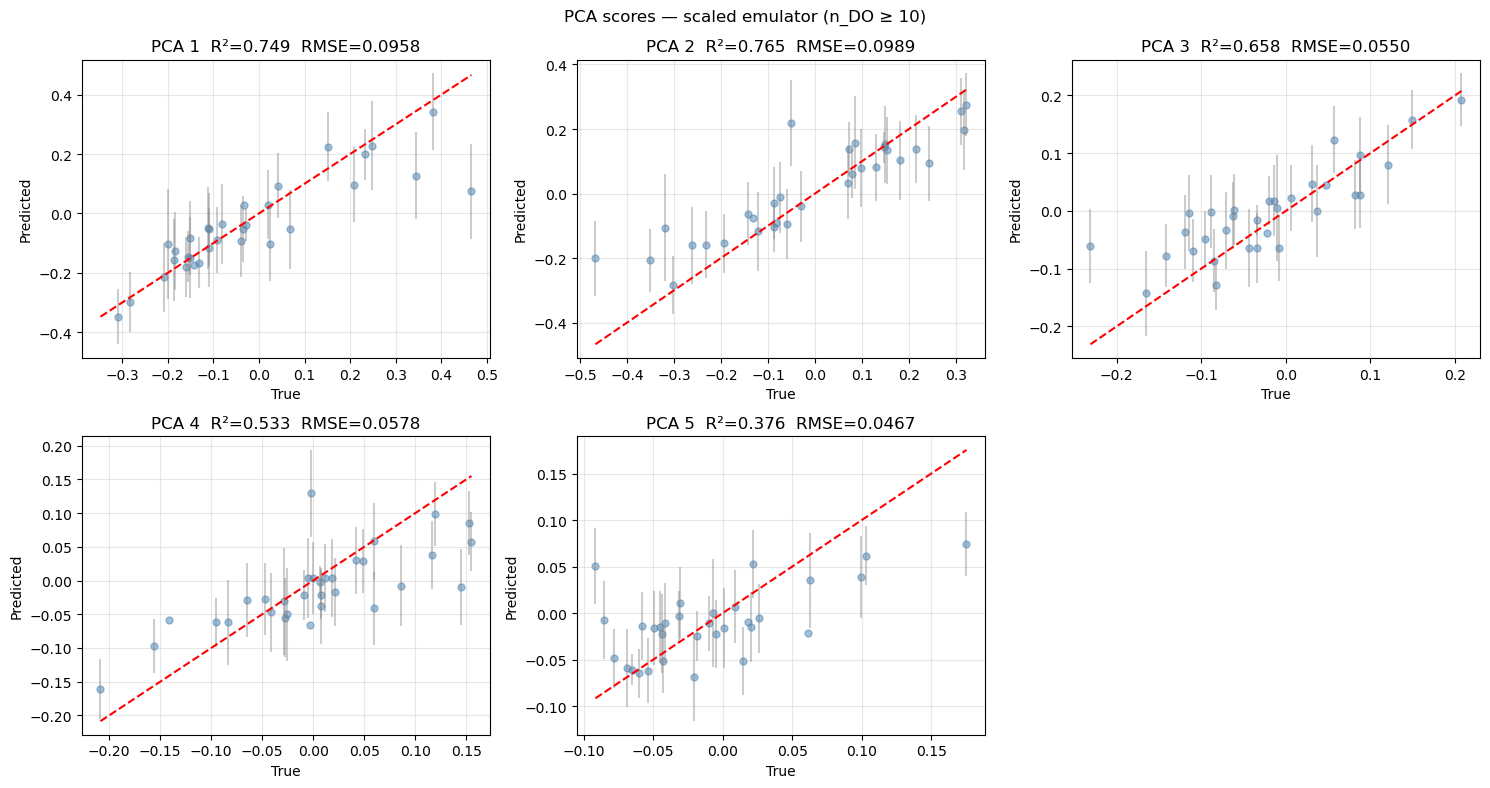

In [15]:
fig = plot_pca_predictions(pca_test, pca_pred, pca_std=pca_std)
plt.suptitle(f'PCA scores — scaled emulator (n_DO ≥ {N_DO_THRESHOLD})', fontsize=12)
plt.tight_layout()
plt.show()

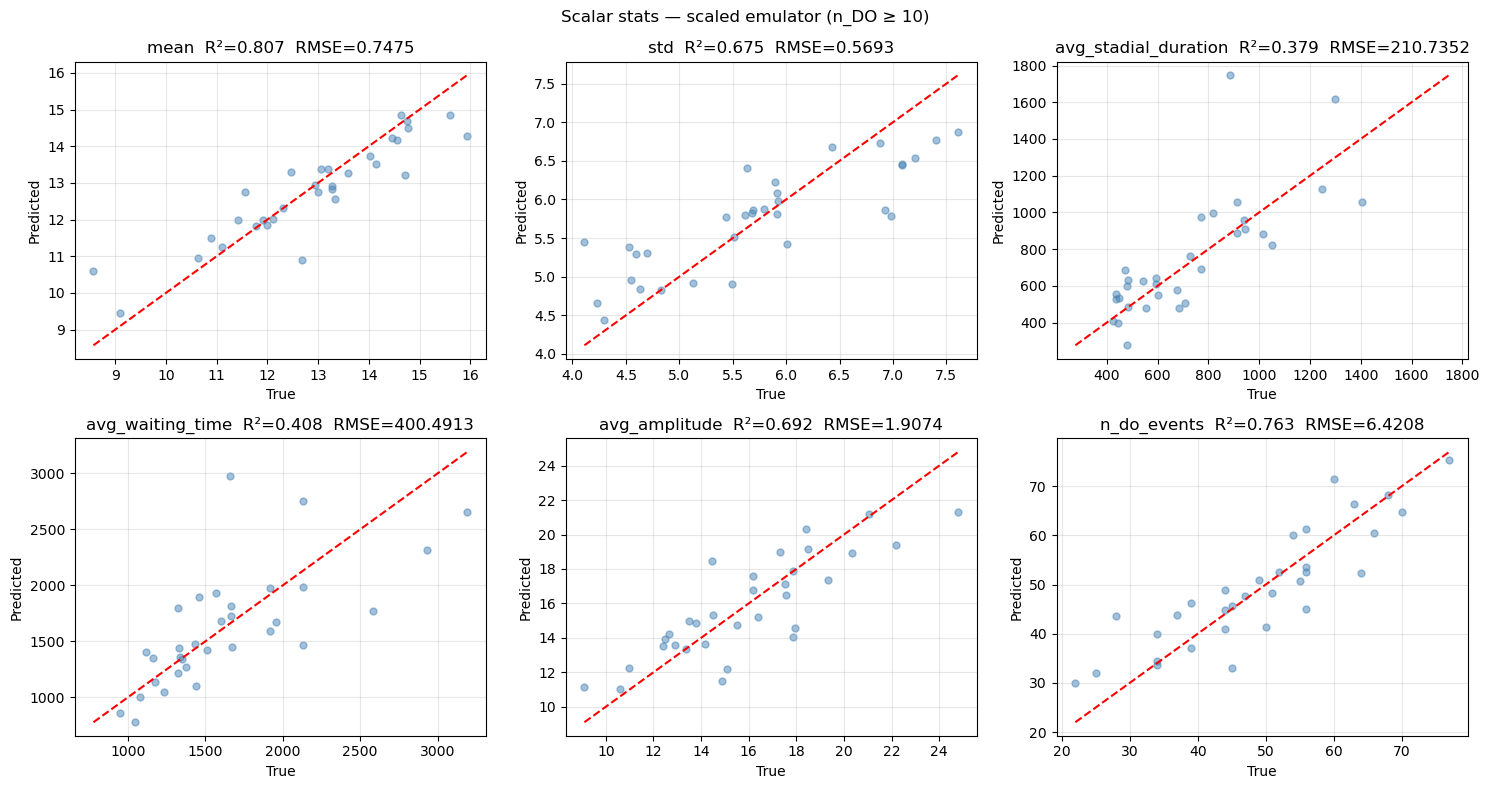

In [16]:
fig = plot_stat_predictions(Y_test, Y_pred, stat_names=STAT_COLS)
plt.suptitle(f'Scalar stats — scaled emulator (n_DO ≥ {N_DO_THRESHOLD})', fontsize=12)
plt.tight_layout()
plt.show()

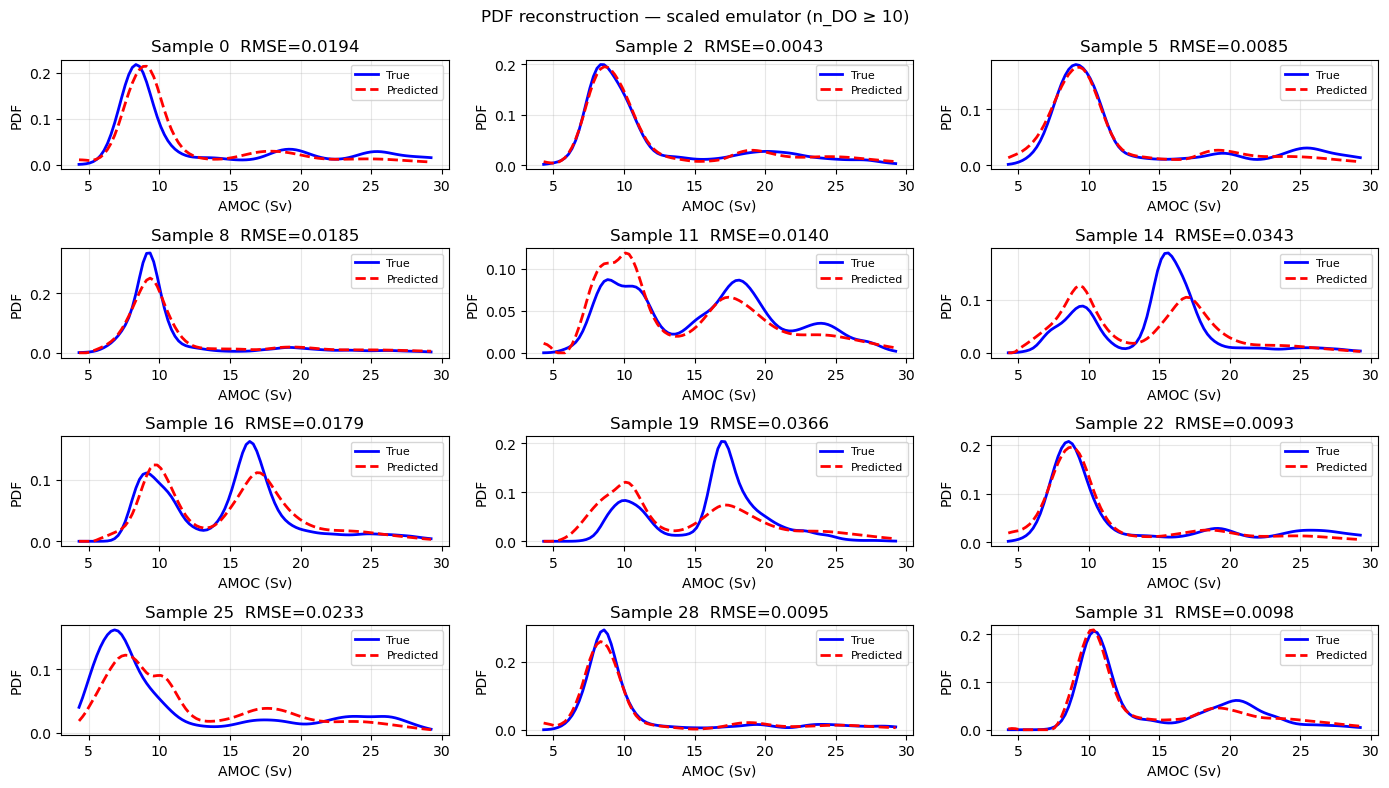

In [17]:
fig = plot_pdf_comparison(pdf_test, pdf_pred, global_x_grid, n_examples=12)
plt.suptitle(f'PDF reconstruction — scaled emulator (n_DO ≥ {N_DO_THRESHOLD})', fontsize=12)
plt.tight_layout()
plt.show()

### 4.5 Predict Default Run

Predicted vs true scalar stats for the default run:
Stat                         Predicted       ±std         True
--------------------------------------------------------------
mean                             12.79      1.023         12.6
std                              6.021      0.591        6.158
avg_stadial_duration             879.8      189.2        813.3
avg_waiting_time                  1437      368.8         1452
avg_amplitude                       20      2.134        18.77
n_do_events                      46.29      7.351           51


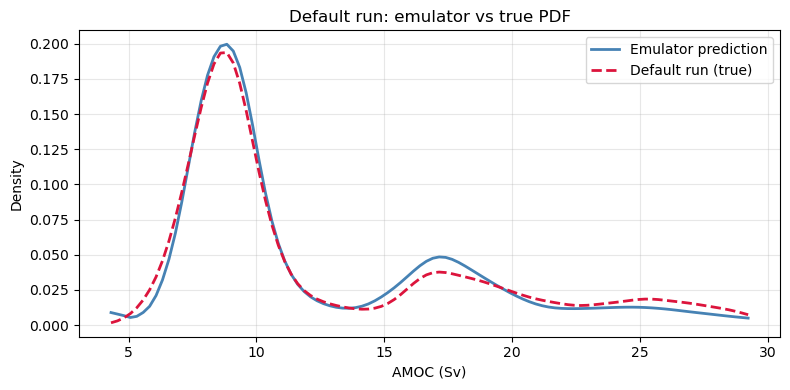

In [18]:
X_default = np.array([[1e-05, 3.0, 0.001, 1500.0, 1500.0, 0.00015]])

pca_pred_def, Y_pred_def, pca_std_def, Y_std_def = emulator.predict(
    X_default, return_std=True
)
pdf_pred_def = emulator.reconstruct_pdf(pca_pred_def)

print('Predicted vs true scalar stats for the default run:')
print(f'{"Stat":<25} {"Predicted":>12} {"±std":>10} {"True":>12}')
print('-' * 62)
for j, name in enumerate(STAT_COLS):
    true_val = default_stats[name] if default_stats is not None else float('nan')
    print(f'{name:<25} {Y_pred_def[0, j]:>12.4g} {Y_std_def[0, j]:>10.4g} {true_val:>12.4g}')

if default_stats is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(global_x_grid, pdf_pred_def.flatten(), label='Emulator prediction', color='steelblue', lw=2)
    ax.plot(global_x_grid, default_stats['pdf'], label='Default run (true)', color='crimson', lw=2, ls='--')
    ax.set_xlabel('AMOC (Sv)')
    ax.set_ylabel('Density')
    ax.set_title('Default run: emulator vs true PDF')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. MCMC in [0, 1] Space

### 5.1 ScaledEmulatorMCMC

| | `EmulatorMCMC` (`mcmc.py`) | `ScaledEmulatorMCMC` (inline) |
|---|---|---|
| Sampling space | log-space φ = log θ | normalised u ∈ [0, 1]^6 |
| Prior | KDE on training samples + log-Jacobian | KDE on training samples (constant Jacobian cancels) |
| Bounds | log(lower), log(upper) | 0, 1 |

The KDE is built in physical parameter space from the filtered training set
(`n_do_events ≥ N_DO_THRESHOLD`) and evaluated at θ = lower + u·(upper − lower).
The Jacobian of the u → θ transform is constant, so it cancels in acceptance
ratios and requires no correction.

In [32]:
import warnings
from scipy.stats import gaussian_kde, norm as _norm
warnings.filterwarnings('ignore')


class ScaledEmulatorMCMC:
    """
    MCMC with sampling directly in normalised [0, 1]^d parameter space.

    Prior   : marginal KDE on training parameters (physical space).
              Evaluated at theta = lower + u*(upper-lower); the Jacobian of
              the u->theta transform is constant and cancels in acceptance ratios.
    DO filter (optional):
              Adds log P(n_do_events >= do_n_threshold) to the log-posterior,
              using the emulator's predicted mean and a total std that folds in
              the CV RMSE.  This softly suppresses parameter combinations where
              the emulator predicts too few DO events, consistent with the
              training-data filter.
    Sampler : emcee.EnsembleSampler.
    """

    def __init__(self, emulator, stat_cols, prior_bounds,
                 obs_targets, obs_sigmas, prior_samples,
                 do_n_threshold=None, do_n_rmse=0.0,
                 nwalkers=64, discrepancy_sigmas=None):
        """
        Parameters
        ----------
        do_n_threshold : float or None
            If set, adds log P(n_do_events >= do_n_threshold) to the
            log-posterior.  Requires 'n_do_events' in stat_cols.
        do_n_rmse : float
            Extra uncertainty on the n_do_events prediction (e.g. CV RMSE).
            Combined in quadrature with the emulator's own predictive std.
        """
        self.emulator      = emulator
        self.stat_cols     = list(stat_cols)
        self.prior_bounds  = dict(prior_bounds)
        self.obs_targets   = dict(obs_targets)
        self.obs_sigmas          = dict(obs_sigmas)
        # Structural model error: gap between model and reality no parameter can close.
        # Zero (default) when calibrating to the model's own output.
        self.discrepancy_sigmas  = dict(discrepancy_sigmas) if discrepancy_sigmas else {}
        self.nwalkers            = nwalkers

        self.param_names = list(prior_bounds.keys())
        self.ndim        = len(self.param_names)

        self.lower = np.array([v[0] for v in prior_bounds.values()])
        self.upper = np.array([v[1] for v in prior_bounds.values()])

        self._prior_kde     = gaussian_kde(prior_samples.T)
        self._prior_samples = prior_samples.copy()

        # DO filter
        self._do_threshold = do_n_threshold
        self._do_rmse      = do_n_rmse
        if do_n_threshold is not None and 'n_do_events' not in self.stat_cols:
            raise ValueError("do_n_threshold requires 'n_do_events' in stat_cols.")

        self._pca_keys  = sorted(
            [k for k in obs_targets if k.startswith('pca_')],
            key=lambda k: int(k.split('_')[1]),
        )
        self._stat_keys = [k for k in obs_targets if not k.startswith('pca_')]
        self._stat_idx  = {k: self.stat_cols.index(k) for k in self._stat_keys}

        self.sampler        = None
        self._samples_u     = None
        self._samples_theta = None
        self._burn_in       = None
        self._thin          = None

    # -- coordinate transform -------------------------------------------------

    def _u_to_theta(self, u):
        return np.asarray(u, dtype=float) * (self.upper - self.lower) + self.lower

    # -- prior ----------------------------------------------------------------

    def log_prior(self, u):
        u = np.asarray(u, dtype=float)
        if np.any(u < 0.0) or np.any(u > 1.0):
            return -np.inf
        theta   = self._u_to_theta(u)
        kde_val = self._prior_kde(theta.reshape(-1, 1))[0]
        if kde_val <= 0.0:
            return -np.inf
        return np.log(kde_val)

    # -- likelihood + DO filter -----------------------------------------------

    def log_likelihood(self, u):
        theta = self._u_to_theta(u).reshape(1, -1)
        pca_p, Y_p, pca_s, Y_s = self.emulator.predict(theta, return_std=True)
        pca_p, pca_s = pca_p.flatten(), pca_s.flatten()
        Y_p,   Y_s   = Y_p.flatten(),   Y_s.flatten()

        ll = 0.0

        # Gaussian likelihood for calibration targets
        for key in self._pca_keys:
            i   = int(key.split('_')[1])
            var = (pca_s[i]**2
                   + self.obs_sigmas[key]**2
                   + self.discrepancy_sigmas.get(key, 0.0)**2)
            ll -= 0.5 * ((self.obs_targets[key] - pca_p[i])**2 / var
                         + np.log(2.0 * np.pi * var))

        for key in self._stat_keys:
            j   = self._stat_idx[key]
            var = (Y_s[j]**2
                   + self.obs_sigmas[key]**2
                   + self.discrepancy_sigmas.get(key, 0.0)**2)
            ll -= 0.5 * ((self.obs_targets[key] - Y_p[j])**2 / var
                         + np.log(2.0 * np.pi * var))

        # Soft DO filter:
        # log P(n_do_events >= threshold) under the emulator's predictive
        # distribution for n_do_events, with total std = sqrt(gp_std^2 + rmse^2).
        #
        #   log norm.cdf((mean - threshold) / std)  ->  0  when mean >> threshold
        #                                           -> -inf when mean << threshold
        #
        # Penalises parameter regions the emulator predicts will have too few
        # DO events, while remaining smooth across the boundary.
        if self._do_threshold is not None:
            j_ndo     = self.stat_cols.index('n_do_events')
            n_do_mean = Y_p[j_ndo]
            n_do_std  = np.sqrt(Y_s[j_ndo]**2 + self._do_rmse**2)
            ll += _norm.logcdf((n_do_mean - self._do_threshold) / n_do_std)

        return ll

    # -- posterior ------------------------------------------------------------

    def log_posterior(self, u):
        lp = self.log_prior(u)
        if not np.isfinite(lp):
            return -np.inf
        ll = self.log_likelihood(u)
        return lp + ll if np.isfinite(ll) else -np.inf

    # -- run ------------------------------------------------------------------

    def run(self, n_steps=10000, burn_in=1000, thin=10, seed=42, progress=True):
        import emcee

        rng    = np.random.default_rng(seed)
        u_init = rng.uniform(0.0, 1.0, (self.nwalkers, self.ndim))

        bad = [i for i in range(self.nwalkers)
               if not np.isfinite(self.log_posterior(u_init[i]))]
        if bad:
            print(f'  {len(bad)} walkers outside support at init -- resampling...')
            for i in bad:
                for _ in range(1000):
                    u_init[i] = rng.uniform(0.0, 1.0, self.ndim)
                    if np.isfinite(self.log_posterior(u_init[i])):
                        break

        do_str = (f', DO filter: n_do >= {self._do_threshold} (rmse={self._do_rmse})'
                  if self._do_threshold is not None else ', no DO filter')
        print(f'emcee: {self.nwalkers} walkers x {n_steps} steps  '
              f'(burn-in {burn_in}, thin {thin}{do_str})')
        print(f'Likelihood terms: {self._pca_keys + self._stat_keys}\n')

        self.sampler = emcee.EnsembleSampler(
            self.nwalkers, self.ndim, self.log_posterior
        )
        self.sampler.run_mcmc(u_init, n_steps, progress=progress)

        self._burn_in     = burn_in
        self._thin        = thin
        self._samples_u   = self.sampler.get_chain(
            discard=burn_in, thin=thin, flat=True
        )
        self._samples_theta = self._u_to_theta(self._samples_u)
        return self

    # -- posterior access -----------------------------------------------------

    @property
    def samples(self):
        if self._samples_theta is None:
            raise RuntimeError('Call run() first.')
        return self._samples_theta

    @property
    def samples_normalised(self):
        if self._samples_u is None:
            raise RuntimeError('Call run() first.')
        return self._samples_u

    # -- diagnostics ----------------------------------------------------------

    def convergence_diagnostics(self):
        acc = self.sampler.acceptance_fraction
        n_s = self._samples_u.shape[0]
        print('=' * 55)
        print('CONVERGENCE DIAGNOSTICS')
        print('=' * 55)
        print(f'Posterior samples      : {n_s}')
        print(f'Acceptance fraction    : {acc.mean():.3f}  '
              f'[{acc.min():.3f} - {acc.max():.3f}]  (ideal: 0.2-0.5)')
        try:
            tau = self.sampler.get_autocorr_time(quiet=True)
            print('\nIntegrated autocorr. time tau (steps):')
            for name, t in zip(self.param_names, tau):
                warn = '  chain too short' if n_s < 50 * t else ''
                print(f'  {name:<22}: {t:6.1f}{warn}')
            print(f'\nMean tau               : {tau.mean():.1f}')
            print(f'Effective samples (N/tau): {n_s / tau.mean():.0f}')
        except Exception as e:
            print(f'\nCould not estimate tau ({e}). Chain may be too short.')
        print('=' * 55)

    # -- chain traces ---------------------------------------------------------

    def plot_chains(self, figsize=None):
        chain = self.sampler.get_chain()
        logp  = self.sampler.get_log_prob()

        n_plots = self.ndim + 1
        figsize = figsize or (14, 2.2 * n_plots)
        fig, axes = plt.subplots(n_plots, 1, figsize=figsize, sharex=True)

        chain_phys = self._u_to_theta(
            chain.reshape(-1, self.ndim)
        ).reshape(chain.shape)

        for ax, name, i in zip(axes, self.param_names, range(self.ndim)):
            ax.plot(chain_phys[:, :, i], color='steelblue', alpha=0.1, lw=0.4)
            ax.set_ylabel(name, fontsize=8)
            ax.axvline(self._burn_in, color='red', ls='--', lw=1, alpha=0.8)
            ax.grid(alpha=0.2)
            ax.tick_params(labelsize=7)

        axes[-1].plot(logp, color='darkorange', alpha=0.1, lw=0.4)
        axes[-1].set_ylabel('log P', fontsize=8)
        axes[-1].axvline(self._burn_in, color='red', ls='--', lw=1,
                         label=f'burn-in ({self._burn_in})')
        axes[-1].legend(fontsize=8, loc='upper right')
        axes[-1].set_xlabel('Step')
        axes[-1].grid(alpha=0.2)

        plt.suptitle('MCMC Chains (physical parameter space)', fontsize=12)
        plt.tight_layout()
        return fig

    # -- 1-D marginal posteriors ----------------------------------------------

    def plot_posterior_1d(self, figsize=None, bins=40, default_params=None):
        n_cols  = 3
        n_rows  = int(np.ceil(self.ndim / n_cols))
        figsize = figsize or (5 * n_cols, 3.5 * n_rows)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        axes = np.array(axes).flatten()

        for i, (ax, name) in enumerate(zip(axes, self.param_names)):
            lo, hi = self.lower[i], self.upper[i]
            grid   = np.linspace(lo, hi, 300)

            prior_k = gaussian_kde(self._prior_samples[:, i])
            prior_d = prior_k(grid)
            prior_d /= np.trapezoid(prior_d, grid)
            ax.fill_between(grid, prior_d, alpha=0.3, color='gray', label='Prior (KDE)')
            ax.plot(grid, prior_d, color='gray', lw=1)

            ax.hist(self.samples[:, i], bins=bins, density=True,
                    alpha=0.75, color='steelblue', label='Posterior', zorder=2)

            q16, med, q84 = np.percentile(self.samples[:, i], [16, 50, 84])
            ax.axvline(med, color='steelblue', lw=2)
            ax.axvspan(q16, q84, alpha=0.2, color='steelblue')
            if default_params is not None:
                ax.axvline(default_params[i], color='red', lw=1.5, ls='--',
                           label='Default', zorder=3)

            ax.axvline(lo, color='dimgray', ls=':', lw=1)
            ax.axvline(hi, color='dimgray', ls=':', lw=1)

            ax.set_title(f'{name}\n{med:.3g}  [{q16:.3g}, {q84:.3g}]', fontsize=9)
            ax.set_xlabel(name, fontsize=8)
            ax.set_ylabel('Density', fontsize=8)
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

        for j in range(self.ndim, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Marginal Posteriors with KDE Prior', fontsize=13)
        plt.tight_layout()
        return fig

    # -- corner plot ----------------------------------------------------------

    def plot_corner(self, **kwargs):
        import corner
        fig = corner.corner(
            self.samples,
            labels=self.param_names,
            show_titles=True,
            title_fmt='.3g',
            quantiles=[0.16, 0.5, 0.84],
            **kwargs,
        )
        return fig

    # -- posterior predictive -------------------------------------------------

    def posterior_predictive(self, n_samples=100, seed=0):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(self.samples),
                         size=min(n_samples, len(self.samples)), replace=False)

        pred_pdfs, pred_stats, pred_pca = [], [], []
        for theta in self.samples[idx]:
            pca_p, Y_p = self.emulator.predict(
                theta.reshape(1, -1), return_std=False
            )
            pred_pdfs.append(self.emulator.reconstruct_pdf(pca_p).flatten())
            pred_stats.append(Y_p.flatten())
            pred_pca.append(pca_p.flatten())

        return np.array(pred_pdfs), np.array(pred_stats), np.array(pred_pca)


print('ScaledEmulatorMCMC class defined.')

ScaledEmulatorMCMC class defined.


In [33]:
# ── Observational uncertainty: window analysis (uses this notebook's own pca_model) ──
# Splits the default CLIMBER-X run into non-overlapping windows and measures how much
# each summary statistic / PCA score varies across windows -- that std is SIGMA_OBS.
# Uses the pca_model fitted above (on this active_datasets' ensemble PDFs) so the PCA
# basis always matches what the emulator/MCMC actually use -- no separate pca_model.pkl.

WINDOW_LENGTHS_OBS = [10_000, 20_000, 30_000]
MIN_DO_EVENTS_OBS  = 5
WINDOW_LENGTH_OBS  = 20_000   # chosen window length used for SIGMA_OBS below

def _stats_for_windows(amoc, time, window_yr, min_do_events=5):
    dt        = np.median(np.diff(time))
    win_steps = int(round(window_yr / dt))
    n_windows = len(amoc) // win_steps
    results = []
    for w in range(n_windows):
        sl = slice(w * win_steps, (w + 1) * win_steps)
        st = compute_summary_stats(
            amoc[sl], time[sl],
            x_grid=global_x_grid,
            spinup_fraction=0.0,
            do_crossing_value=5.0,
            detection_mode='peak_walkback',
            do_peak_threshold=do_peak_threshold,
        )
        if not st['do_variability'] or st['n_do_events'] < min_do_events:
            continue
        st['pca_components'] = pca_model.transform(st['pdf'].reshape(1, -1)).flatten()
        results.append(st)
    return results

s0_obs   = int(len(amoc_default_raw) * 0.02)
amoc_obs = amoc_default_raw[s0_obs:]
time_obs = time_default_raw[s0_obs:]

window_results_obs = {
    W: _stats_for_windows(amoc_obs, time_obs, W, MIN_DO_EVENTS_OBS)
    for W in WINDOW_LENGTHS_OBS
}

wstats = window_results_obs[WINDOW_LENGTH_OBS]
print(f'Window analysis ({WINDOW_LENGTH_OBS} yr): {len(wstats)} valid windows'
      + ('  *** <10 windows: estimates unreliable ***' if len(wstats) < 10 else ''))

SIGMA_STAT_OBS = {}
for key in STAT_COLS:
    vals = np.array([s[key] for s in wstats if key in s])
    SIGMA_STAT_OBS[key] = float(vals.std(ddof=1)) if len(vals) > 1 else float('nan')

SIGMA_PCA_OBS = np.array([
    np.array([s['pca_components'][i] for s in wstats]).std(ddof=1)
    for i in range(N_PCA)
])

print('\nSIGMA_PCA_OBS  :', np.round(SIGMA_PCA_OBS, 4))
print('SIGMA_STAT_OBS :')
for k, v in SIGMA_STAT_OBS.items():
    print(f'  {k:<25}: {v:.4g}')

print('\nAcross window lengths (for comparison):')
for W, res in window_results_obs.items():
    n = len(res)
    warn = '  (few windows)' if n < 10 else ''
    print(f'  {W:>6} yr -> {n} windows{warn}')


Window analysis (20000 yr): 3 valid windows  *** <10 windows: estimates unreliable ***

SIGMA_PCA_OBS  : [0.0489 0.0772 0.0212 0.0093 0.0053]
SIGMA_STAT_OBS :
  mean                     : 0.3109
  std                      : 0.1498
  avg_stadial_duration     : 166.6
  avg_waiting_time         : 234
  avg_amplitude            : 1.685
  n_do_events              : 2.309

Across window lengths (for comparison):
   10000 yr -> 5 windows  (few windows)
   20000 yr -> 3 windows  (few windows)
   30000 yr -> 2 windows  (few windows)


### 5.2 Train Inference Emulator & Configure MCMC

In [34]:
# ── MCMC configuration ────────────────────────────────────────────────────────
MCMC_N_STEPS  = 12000
MCMC_BURN_IN  = 5000
MCMC_THIN     = 10
MCMC_NWALKERS = 64

# SIGMA_PCA_OBS / SIGMA_STAT_OBS computed above from window analysis of the
# default run, using this notebook's own pca_model (previous cell).

# Likelihood targets: PCA 0-4 + avg_waiting_time
MCMC_STAT_TARGETS = ['avg_waiting_time']

# DO filter: soft threshold on predicted n_do_events.
# DO_N_RMSE folds in the CV RMSE (4.8) so the threshold has appropriate width;
# set to 0.0 to use only the GP's own predictive std.
DO_N_RMSE = 4.8   # from 5-fold CV

# Per-output std floor from CV RMSE — prevents GP overconfidence.
# Order: [pca_0..pca_4, mean, std, avg_stadial_dur, avg_waiting_time, avg_amp, n_do]
CV_RMSE_PCA  = np.array([0.0838, 0.0435, 0.0556, 0.0488, 0.0302])
CV_RMSE_STAT = np.array([0.41,   0.45,   0.0,    283.0,  0.0,       4.8])
MIN_STD = np.concatenate([CV_RMSE_PCA, CV_RMSE_STAT])

# ── Full-data emulator for inference (all n_DO >= 20 runs, no held-out fold) ──
emulator_mcmc = GPEmulatorPDF(
    kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
    scaler_X=BoundsScaler(lower, upper),
    scaler_y=StandardScaler(),
    min_std=MIN_STD,
)
emulator_mcmc.pca         = pca_model
emulator_mcmc.pdf_xpoints = global_x_grid
emulator_mcmc.fit(X, other_stats, pca_components)

print(f'Inference emulator trained on {len(X)} runs  (n_DO >= {N_DO_THRESHOLD})')
print(f'MCMC: {MCMC_NWALKERS} walkers x {MCMC_N_STEPS} steps  '
      f'(burn-in {MCMC_BURN_IN}, thin {MCMC_THIN})')
print(f'DO filter: n_do >= {N_DO_THRESHOLD}, RMSE = {DO_N_RMSE}')


Inference emulator trained on 160 runs  (n_DO >= 10)
MCMC: 64 walkers x 12000 steps  (burn-in 5000, thin 10)
DO filter: n_do >= 10, RMSE = 4.8


In [35]:
# ── Calibration targets from the default run ──────────────────────────────────
obs_targets = {f'pca_{i}': default_stats['pca_components'][i] for i in range(N_PCA)}
for key in MCMC_STAT_TARGETS:
    obs_targets[key] = default_stats[key]

obs_sigmas = {f'pca_{i}': SIGMA_PCA_OBS[i] for i in range(N_PCA)}
for key in MCMC_STAT_TARGETS:
    obs_sigmas[key] = SIGMA_STAT_OBS[key]

print('Calibration targets:')
for k, v in obs_targets.items():
    print(f'  {k:<25}: {v:10.4f}  +-  {obs_sigmas[k]:.4f}')

# ── Instantiate ───────────────────────────────────────────────────────────────
mcmc = ScaledEmulatorMCMC(
    emulator=emulator_mcmc,
    stat_cols=STAT_COLS,
    prior_bounds=prior_bounds,
    obs_targets=obs_targets,
    obs_sigmas=obs_sigmas,
    prior_samples=X,
    do_n_threshold=N_DO_THRESHOLD,   # soft DO filter
    do_n_rmse=DO_N_RMSE,             # CV RMSE folded into filter width
    nwalkers=MCMC_NWALKERS,
)


Calibration targets:
  pca_0                    :     0.0037  +-  0.0489
  pca_1                    :     0.0918  +-  0.0772
  pca_2                    :    -0.0626  +-  0.0212
  pca_3                    :     0.0602  +-  0.0093
  pca_4                    :    -0.0152  +-  0.0053
  avg_waiting_time         :  1451.9200  +-  233.9686


### 5.3 Run Sampler

In [36]:
mcmc.run(
    n_steps=MCMC_N_STEPS,
    burn_in=MCMC_BURN_IN,
    thin=MCMC_THIN,
    seed=42,
    progress=True,
)

print(f'\nPosterior sample shape: {mcmc.samples.shape}')
print('Parameter medians (physical space):')
for i, name in enumerate(mcmc.param_names):
    q16, med, q84 = np.percentile(mcmc.samples[:, i], [16, 50, 84])
    print(f'  {name:<22}: {med:.5g}  [{q16:.5g}, {q84:.5g}]')

emcee: 64 walkers x 12000 steps  (burn-in 5000, thin 10, DO filter: n_do >= 10 (rmse=4.8))
Likelihood terms: ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'avg_waiting_time']



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12000/12000 [02:47<00:00, 71.76it/s]


Posterior sample shape: (44800, 6)
Parameter medians (physical space):
  diff_dia_min          : 1.0689e-05  [7.1236e-06, 1.4203e-05]
  drag_topo_fac         : 3.0304  [2.6856, 3.3782]
  slope_max             : 0.0014923  [0.001085, 0.0018622]
  diff_iso              : 1452.2  [1052.9, 1782.9]
  diff_gm               : 1443.4  [1065.9, 1772.8]
  diff_dia_max          : 0.00015746  [0.00012334, 0.00018801]


### 5.4 Convergence Diagnostics

In [37]:
mcmc.convergence_diagnostics()

CONVERGENCE DIAGNOSTICS
Posterior samples      : 44800
Acceptance fraction    : 0.398  [0.379 - 0.413]  (ideal: 0.2-0.5)

Integrated autocorr. time tau (steps):
  diff_dia_min          :  120.3
  drag_topo_fac         :  124.1
  slope_max             :  119.2
  diff_iso              :  120.3
  diff_gm               :  141.2
  diff_dia_max          :  122.4

Mean tau               : 124.6
Effective samples (N/tau): 360


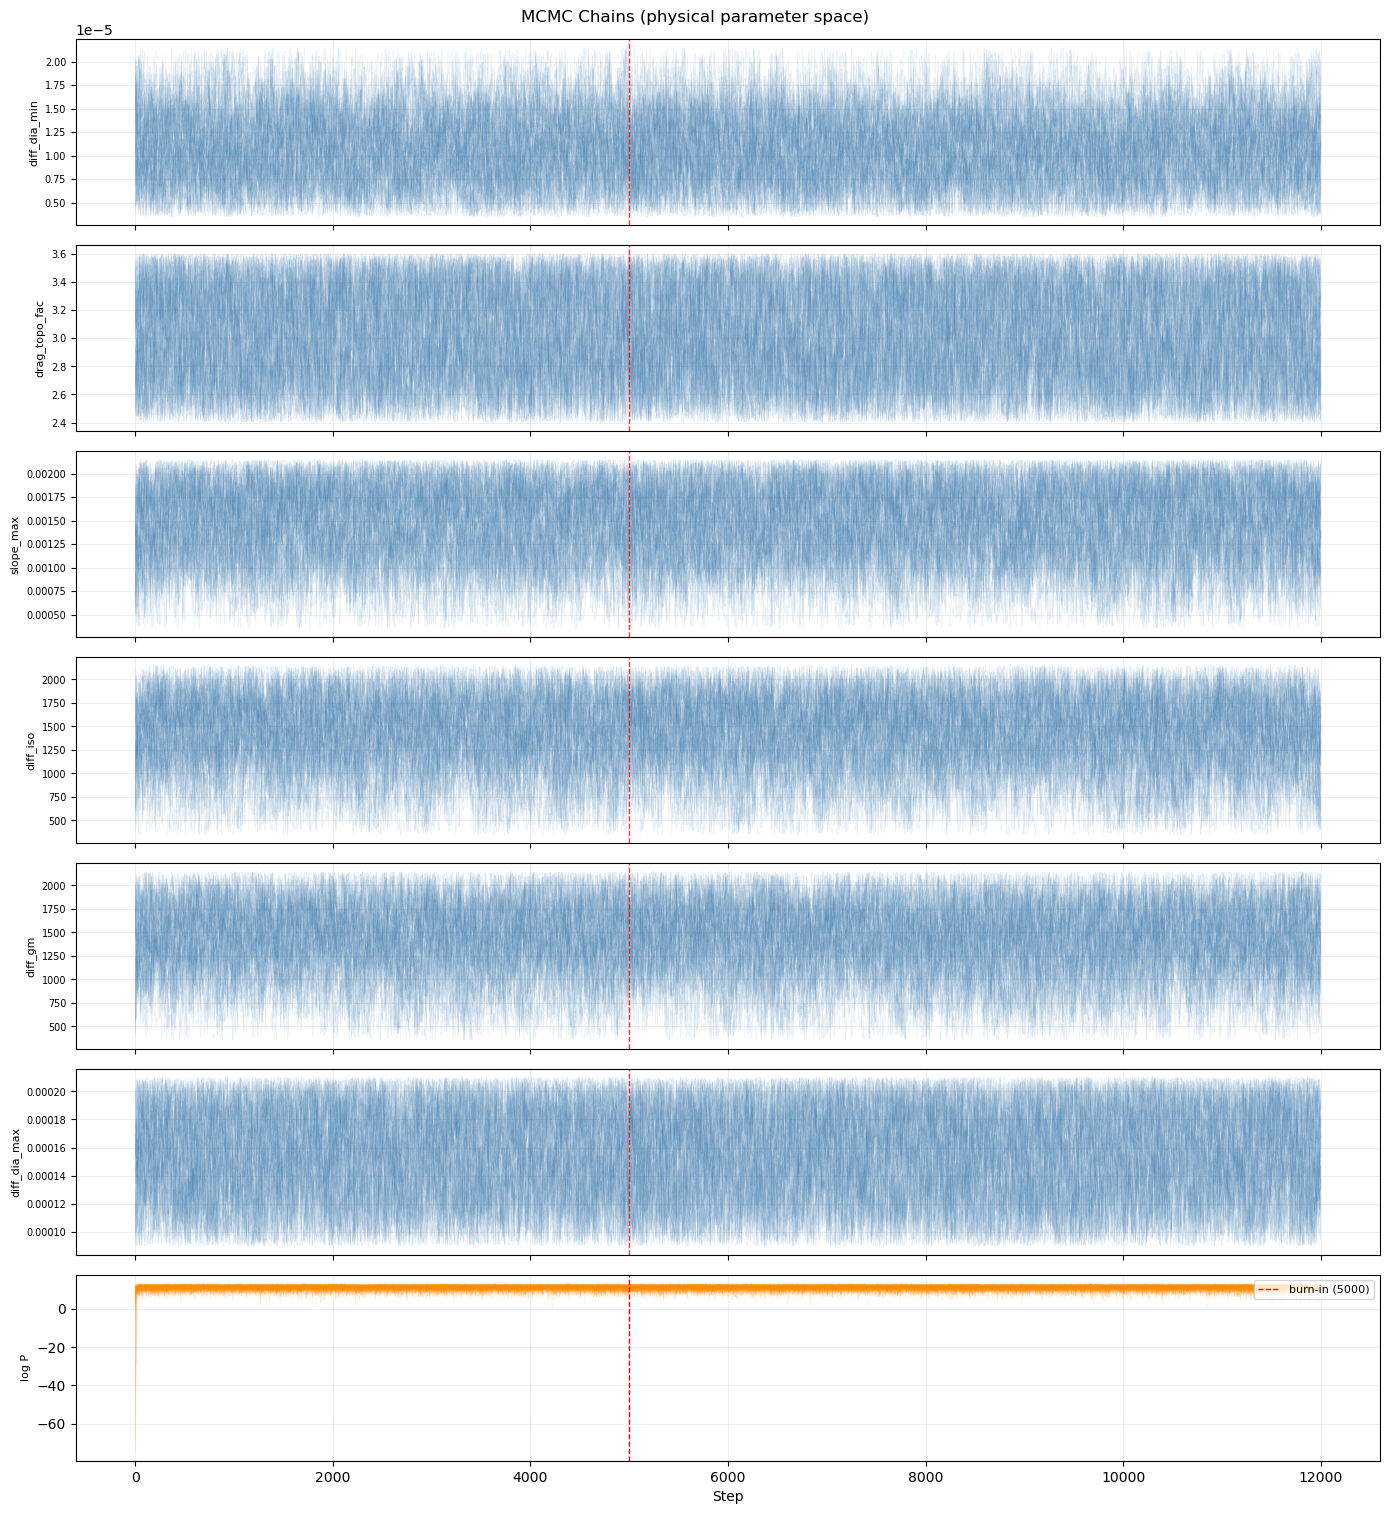

In [38]:
fig = mcmc.plot_chains()
plt.show()

### 5.5 Marginal Posteriors

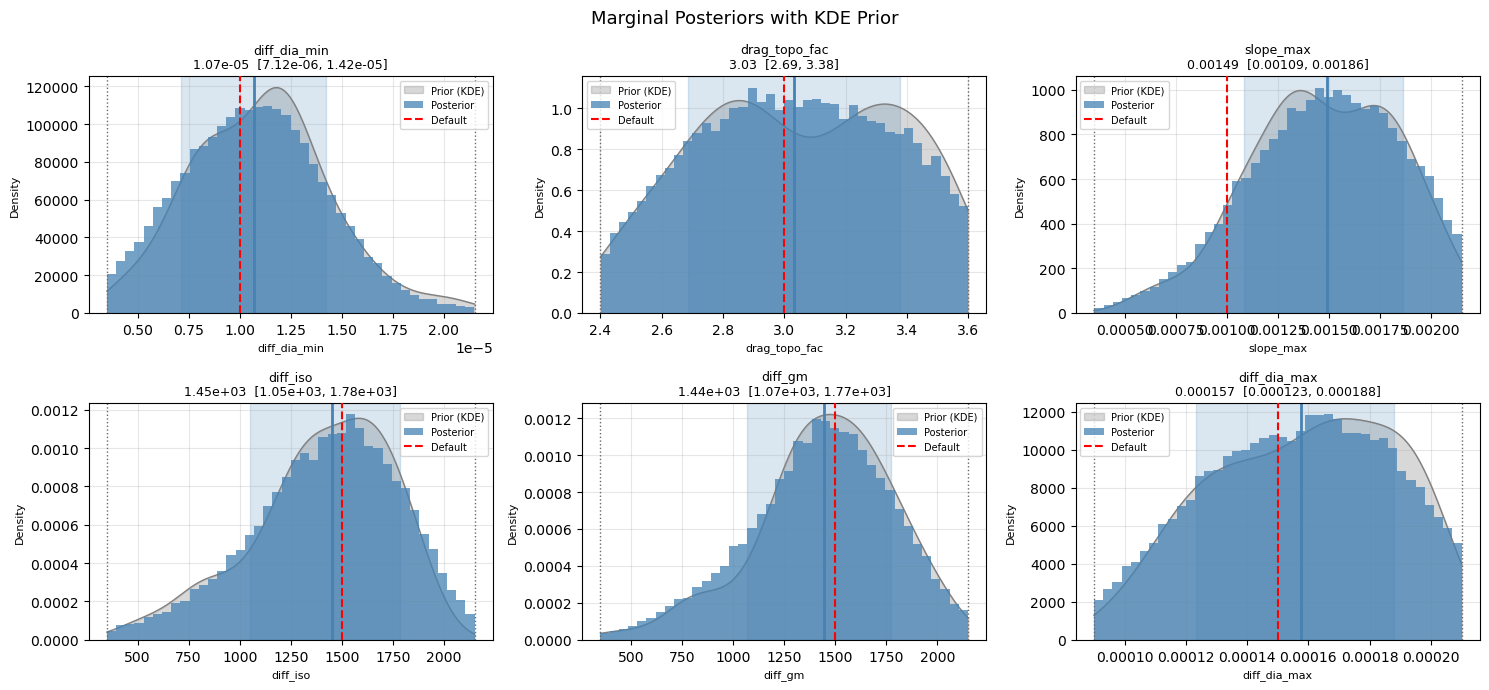

In [39]:
fig = mcmc.plot_posterior_1d(default_params=PARAMS_DEFAULT_ARR)
plt.show()


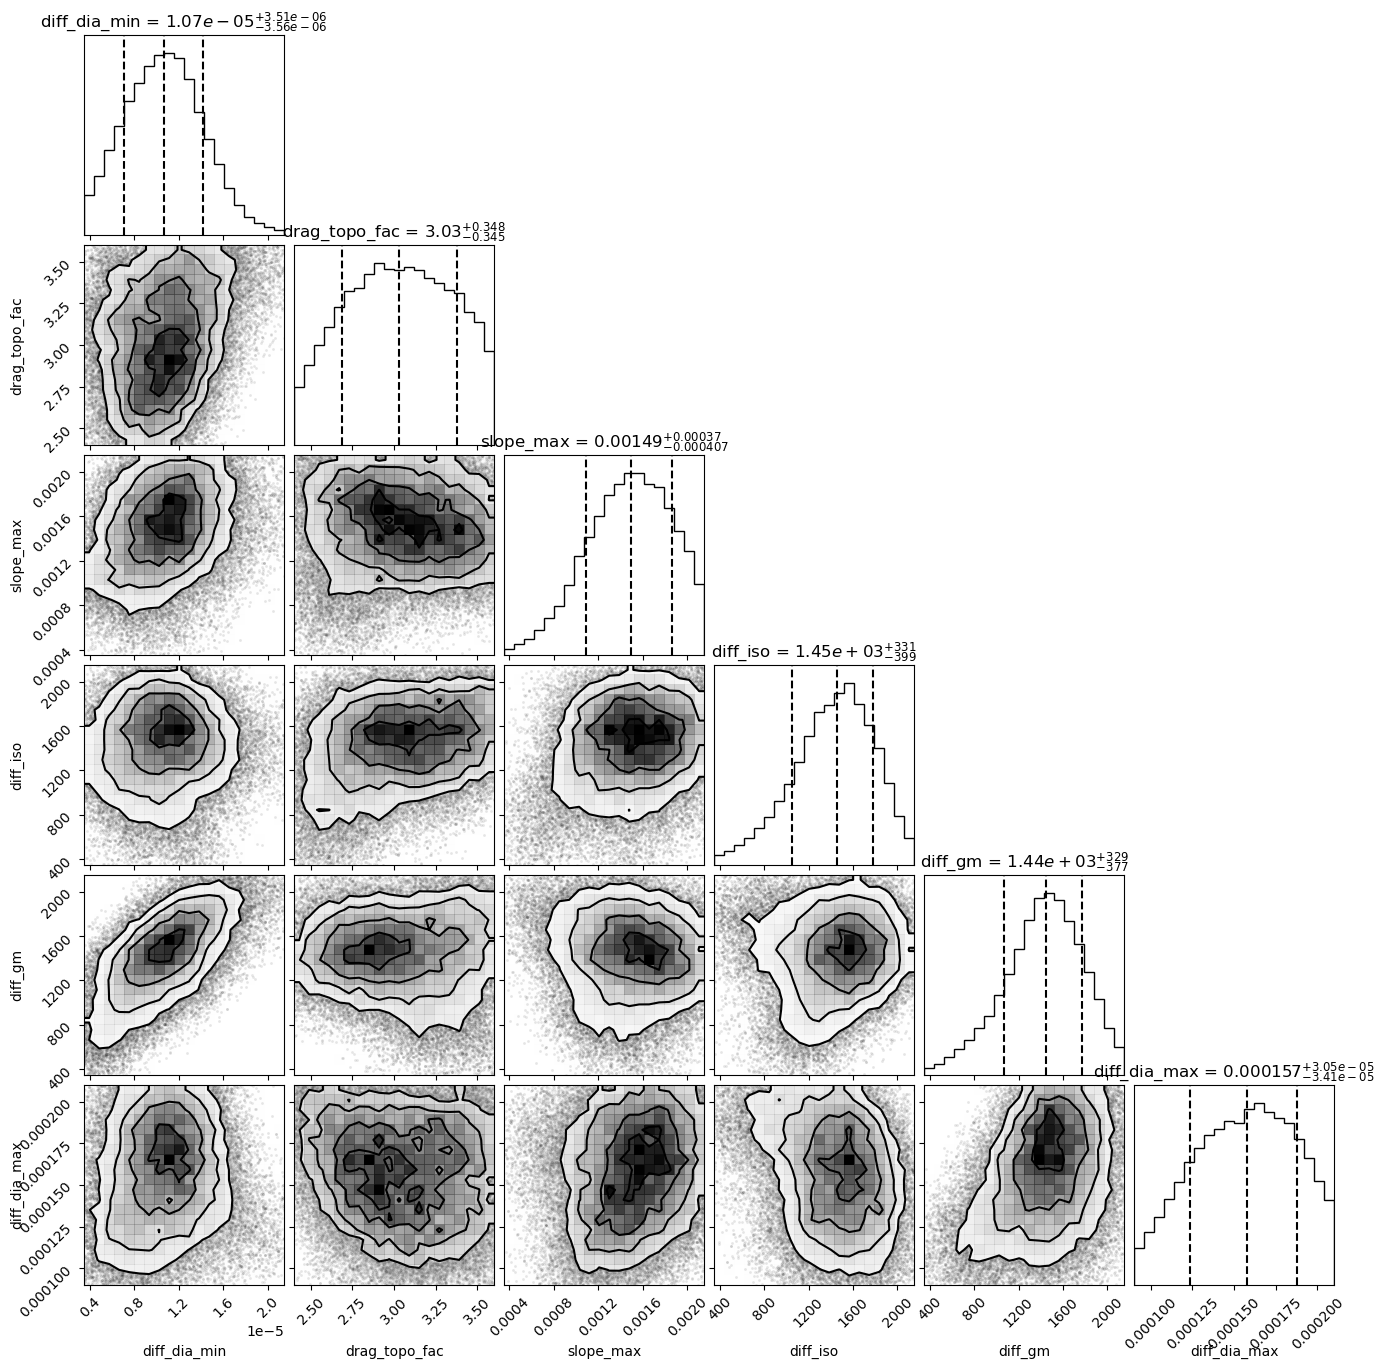

In [40]:
try:
    fig = mcmc.plot_corner()
    plt.show()
except ImportError:
    print("Install the 'corner' package for the joint posterior plot.")

### 5.6 Posterior Predictive

In [41]:
pred_pdfs, pred_stats, pred_pca = mcmc.posterior_predictive(n_samples=100, seed=0)
print(f'Posterior predictive samples: {len(pred_pdfs)}')

Posterior predictive samples: 100


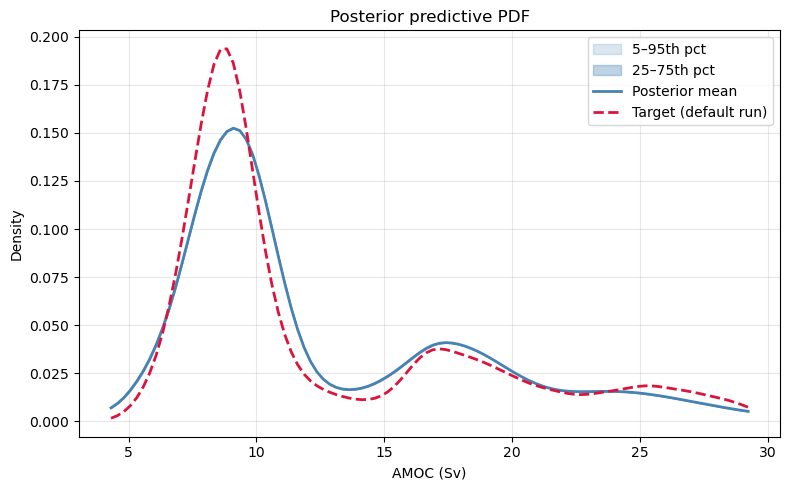

In [42]:
# ── PDF envelope ──────────────────────────────────────────────────────────────
mean_pdf = pred_pdfs.mean(0)
q5,  q95 = np.percentile(pred_pdfs, [ 5, 95], axis=0)
q25, q75 = np.percentile(pred_pdfs, [25, 75], axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(global_x_grid, q5,  q95,  alpha=0.20, color='steelblue', label='5–95th pct')
ax.fill_between(global_x_grid, q25, q75,  alpha=0.35, color='steelblue', label='25–75th pct')
ax.plot(global_x_grid, mean_pdf, color='steelblue', lw=2, label='Posterior mean')
if default_stats is not None:
    ax.plot(global_x_grid, default_stats['pdf'], color='crimson', lw=2, ls='--',
            label='Target (default run)')
ax.set_xlabel('AMOC (Sv)')
ax.set_ylabel('Density')
ax.set_title('Posterior predictive PDF')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

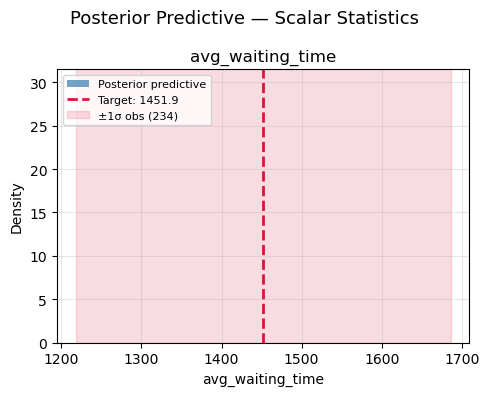

In [43]:
# ── Scalar stat histograms ────────────────────────────────────────────────────
stat_keys = [k for k in obs_targets if not k.startswith('pca_')]
n         = len(stat_keys)
fig, axes = plt.subplots(1, max(n, 1), figsize=(5 * max(n, 1), 4))
if n == 1:
    axes = [axes]

for ax, key in zip(axes, stat_keys):
    j      = STAT_COLS.index(key)
    vals   = pred_stats[:, j]
    target = obs_targets[key]
    sigma  = obs_sigmas.get(key)

    ax.hist(vals, bins=30, density=True, alpha=0.75,
            color='steelblue', label='Posterior predictive')
    ax.axvline(target, color='crimson', lw=2, ls='--',
               label=f'Target: {target:.1f}')
    if sigma is not None:
        ax.axvspan(target - sigma, target + sigma,
                   alpha=0.15, color='crimson', label=f'±1σ obs ({sigma:.0f})')
    ax.set_xlabel(key)
    ax.set_ylabel('Density')
    ax.set_title(key)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Posterior Predictive — Scalar Statistics', fontsize=13)
plt.tight_layout()
plt.show()

### 5.6b Forward-Pass Parameter Sampling (main MCMC run)

Draw independent parameter sets from this main posterior (`mcmc.samples`'s
underlying chain) to hand back to the full CLIMBER-X model as a forward-pass
ensemble. Independence is enforced by re-thinning the **raw** chain by its own
integrated autocorrelation time τ, rather than reusing `MCMC_THIN` (which is
much shorter than τ and leaves residual correlation between samples).

Written in the same `params.txt` format as `find_DO_region.ipynb` (header row
of `ocn.*` names, one run per line, `%.18e` formatting).

Placed here — right after the main run — rather than after §5.7 below, since
the threshold-sensitivity MCMC runs are experimental and not the ones used
for the forward pass.

In [44]:
# ── Rigorous independent sampling from the posterior ───────────────────
# MCMC_THIN (used to build mcmc.samples) is far shorter than the chain's own
# integrated autocorrelation time, so consecutive entries there are still
# correlated. Re-thin the raw chain by its own tau for genuinely independent draws.

tau_raw    = mcmc.sampler.get_autocorr_time(quiet=True)
thin_indep = int(np.ceil(tau_raw.max()))
print('Integrated autocorrelation time (raw steps):')
for name, t in zip(mcmc.param_names, tau_raw):
    print(f'  {name:<22}: {t:6.1f}')
print(f'Using thin = {thin_indep} raw steps for independent draws (max over parameters)')

samples_u_indep = mcmc.sampler.get_chain(discard=MCMC_BURN_IN, thin=thin_indep, flat=True)
samples_indep   = samples_u_indep * (mcmc.upper - mcmc.lower) + mcmc.lower
print(f'Independent posterior pool: {len(samples_indep)} samples '
      f'(vs {len(mcmc.samples)} in the thin={MCMC_THIN} pool used elsewhere in this notebook)')

N_FORWARD_SAMPLES  = 100
FORWARD_OUTPUT_DIR = 'forward_pass_sampled_from_200'
os.makedirs(FORWARD_OUTPUT_DIR, exist_ok=True)

if len(samples_indep) < N_FORWARD_SAMPLES:
    raise ValueError(
        f'Only {len(samples_indep)} independent samples available, need '
        f'{N_FORWARD_SAMPLES}. Increase MCMC_N_STEPS/MCMC_NWALKERS to get more.'
    )

rng_forward    = np.random.default_rng(0)
idx_forward    = rng_forward.choice(len(samples_indep), size=N_FORWARD_SAMPLES, replace=False)
forward_params = samples_indep[idx_forward]   # (100, 6) physical parameter space

df_forward = pd.DataFrame(forward_params, columns=param_cols)

params_file = f'{FORWARD_OUTPUT_DIR}/params.txt'
with open(params_file, 'w') as f:
    f.write(' '.join(param_cols) + '\n')
    for _, row in df_forward.iterrows():
        f.write(' '.join(f'{row[col]:.18e}' for col in param_cols) + '\n')

print(f'\nWritten {params_file}  ({len(df_forward)} runs)')
print(df_forward.describe().round(6))


Integrated autocorrelation time (raw steps):
  diff_dia_min          :  120.3
  drag_topo_fac         :  124.1
  slope_max             :  119.2
  diff_iso              :  120.3
  diff_gm               :  141.2
  diff_dia_max          :  122.4
Using thin = 142 raw steps for independent draws (max over parameters)
Independent posterior pool: 3136 samples (vs 44800 in the thin=10 pool used elsewhere in this notebook)

Written forward_pass_sampled_from_200/params.txt  (100 runs)
       ocn.diff_dia_min  ocn.drag_topo_fac  ocn.slope_max  ocn.diff_iso  \
count        100.000000         100.000000     100.000000    100.000000   
mean           0.000011           3.023857       0.001480   1416.064655   
std            0.000004           0.325788       0.000378    340.121880   
min            0.000004           2.407688       0.000490    411.691851   
25%            0.000008           2.772284       0.001252   1187.940815   
50%            0.000011           3.027015       0.001455   1444.07148

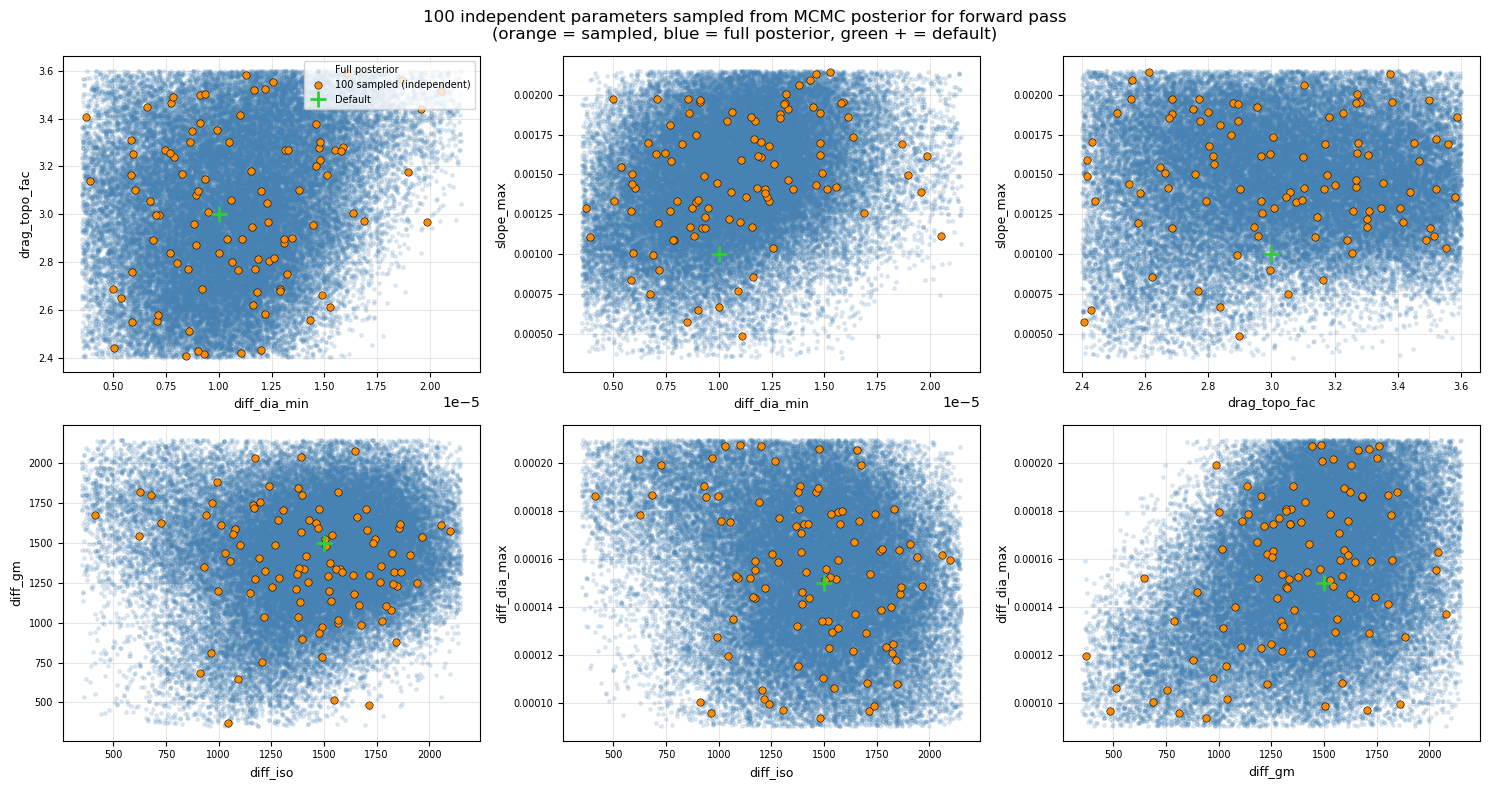

In [45]:
# ── 2-D scatter of the sampled forward-pass parameters ──────────────────
pairs = [(0, 1), (0, 2), (1, 2), (3, 4), (3, 5), (4, 5)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (i, j) in zip(axes.ravel(), pairs):
    ax.scatter(mcmc.samples[:, i], mcmc.samples[:, j],
               c='steelblue', s=6, alpha=0.15, zorder=2, label='Full posterior')
    ax.scatter(forward_params[:, i], forward_params[:, j],
               c='darkorange', s=28, edgecolors='k', linewidths=0.4,
               zorder=3, label=f'{N_FORWARD_SAMPLES} sampled (independent)')
    ax.plot(PARAMS_DEFAULT_ARR[i], PARAMS_DEFAULT_ARR[j],
            '+', color='limegreen', ms=12, mew=2, zorder=4, label='Default')
    ax.set_xlabel(param_names[i], fontsize=9)
    ax.set_ylabel(param_names[j], fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
axes.ravel()[0].legend(fontsize=7, loc='upper right')
plt.suptitle(
    f'{N_FORWARD_SAMPLES} independent parameters sampled from MCMC posterior for forward pass\n'
    f'(orange = sampled, blue = full posterior, green + = default)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{FORWARD_OUTPUT_DIR}/forward_pass_params_2d.pdf', dpi=150, bbox_inches='tight')
plt.show()


### 5.7 Threshold Sensitivity: Posterior Comparison

Run MCMC for three exclusion thresholds (`n_do_events ≥ 10 / 20 / 30`) and
overlay the 1-D marginal posteriors to show how much the threshold choice
affects the inferred parameter distributions.
Each emulator is trained from scratch on the DO runs filtered to the given
threshold, using the same `BoundsScaler` and `ScaledEmulatorMCMC`.

In [31]:
COMPARE_THRESHOLDS = [10, 20, 30]
threshold_posteriors = {}   # {t: {'samples': ..., 'prior_samples': ...}}
n_do_col_cmp = STAT_COLS.index('n_do_events')

for t in COMPARE_THRESHOLDS:
    print(f'\n{"="*54}')
    print(f'  n_do_events \u2265 {t}')
    print(f'{"="*54}')

    keep_t  = Y_do[:, n_do_col_cmp] >= t
    X_t     = X_do[keep_t]
    Y_t     = Y_do[keep_t]
    pca_t   = pca_do[keep_t]
    print(f'  Training runs : {keep_t.sum()} / {len(X_do)}  ({(~keep_t).sum()} excluded)')

    em_t = GPEmulatorPDF(
        kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
        scaler_X=BoundsScaler(lower, upper),
        scaler_y=StandardScaler(),
        min_std=MIN_STD,
    )
    em_t.pca         = pca_model
    em_t.pdf_xpoints = global_x_grid
    em_t.fit(X_t, Y_t, pca_t)

    obs_t = {f'pca_{i}': default_stats['pca_components'][i] for i in range(N_PCA)}
    for key in MCMC_STAT_TARGETS:
        obs_t[key] = default_stats[key]

    sig_t = {f'pca_{i}': SIGMA_PCA_OBS[i] for i in range(N_PCA)}
    for key in MCMC_STAT_TARGETS:
        sig_t[key] = SIGMA_STAT_OBS[key]

    mcmc_t = ScaledEmulatorMCMC(
        emulator=em_t,
        stat_cols=STAT_COLS,
        prior_bounds=prior_bounds,
        obs_targets=obs_t,
        obs_sigmas=sig_t,
        prior_samples=X_t,
        do_n_threshold=t,
        do_n_rmse=DO_N_RMSE,
        nwalkers=MCMC_NWALKERS,
    )
    mcmc_t.run(n_steps=MCMC_N_STEPS, burn_in=MCMC_BURN_IN, thin=MCMC_THIN,
               seed=42, progress=True)

    threshold_posteriors[t] = {
        'samples':       mcmc_t.samples,
        'prior_samples': X_t,
    }
    print(f'  Posterior samples : {mcmc_t.samples.shape[0]}')

print('\nAll threshold runs complete.')



  n_do_events ≥ 10
  Training runs : 160 / 166  (6 excluded)
emcee: 64 walkers x 12000 steps  (burn-in 5000, thin 10, DO filter: n_do >= 10 (rmse=4.8))
Likelihood terms: ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'avg_waiting_time']



 32%|███████████████████████████████████████████████████████████████████                                                                                                                                            | 3889/12000 [00:55<01:52, 72.04it/s]Traceback (most recent call last):
  File "/home/karinako/miniconda3/envs/emulator/lib/python3.11/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_76475/200035647.py", line 138, in log_posterior
    lp = self.log_prior(u)
         ^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_76475/200035647.py", line 83, in log_prior
    if np.any(u < 0.0) or np.any(u > 1.0):
                          ^^^^^^^^^^^^^^^
  File "/home/karinako/miniconda3/envs/emulator/lib/python3.11/site-packages/numpy/_core/fromnumeric.py", line 2395, in _any_dispatcher
    def _any_dispatcher(a, axis=None, out=None, keepdims=None, *,
    
KeyboardInterrupt


emcee: Exception while calling your likelihood function:
  params: [0.08400707 0.6639334  0.45570747 0.40625772 0.23486987 0.4175848 ]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [ ]:
from scipy.stats import gaussian_kde as _gkde

n_cols = 3
n_rows = int(np.ceil(len(param_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).flatten()

COMPARE_COLORS = {10: 'steelblue', 20: 'darkorange', 30: 'seagreen'}

for i, (ax, name) in enumerate(zip(axes, param_names)):
    lo, hi = prior_bounds[name]
    grid   = np.linspace(lo, hi, 300)

    for t, col in COMPARE_COLORS.items():
        pr_samps   = threshold_posteriors[t]['prior_samples']
        post_samps = threshold_posteriors[t]['samples']
        n_train    = len(pr_samps)

        # Prior marginal KDE (dashed fill)
        pr_k = _gkde(pr_samps[:, i])
        pr_d = pr_k(grid)
        pr_d /= np.trapezoid(pr_d, grid)
        ax.fill_between(grid, pr_d, alpha=0.07, color=col)
        ax.plot(grid, pr_d, color=col, lw=0.9, ls='--')

        # Posterior histogram
        ax.hist(post_samps[:, i], bins=40, density=True,
                alpha=0.40, color=col, label=f'\u2265{t}  (n={n_train})')

        # Posterior median
        ax.axvline(np.median(post_samps[:, i]), color=col, lw=1.5)

    ax.axvline(PARAMS_DEFAULT_ARR[i], color='red', lw=1.5, ls='--',
               label='Default', zorder=3)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel(name, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8, title='n_do threshold', title_fontsize=8)

for j in range(len(param_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Posterior sensitivity to n_do_events exclusion threshold  [scaled emulator]\n'
    '(dashed fill = prior, solid bars = posterior, vertical line = median)',
    fontsize=12,
)
plt.tight_layout()
plt.show()